# Build the eddy-centre stratification cache

This notebook calculates environmental buoyancy frequency and writes one row per existing eddy-day. It **does not calculate or modify tilt**. `xroms.potential_density(..., z=0)` supplies surface-referenced potential density, then $N^2=-g\rho_0^{-1}\partial\sigma_0/\partial z$ is evaluated down each requested column. Using potential rather than pressure-dependent in-situ density prevents adiabatic compression from being misidentified as stratification. The cache contains fixed-depth mean, integral, and maximum $N^2$ over 0–200 and 0–500 m, plus pycnocline-following mean/maximum $N^2$, pycnocline depth, and density-threshold mixed-layer depth.

The build is restartable and parallel by 30-day ROMS file. Within each file, all eddy centres required on a timestep are selected together and computed once. Completed files are stored under a partition folder containing a hash of the scientific settings, so partitions cannot be silently reused after changing the method, depths, MLD threshold, or pycnocline window.

Run this once on Katana before notebook 02. Inspect the model variable names and the sign/range checks before accepting the cache.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

HERE = Path.cwd()
ANALYSIS_ROOT = HERE.parent
if str(ANALYSIS_ROOT) not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT))
if str(ANALYSIS_ROOT / "beta_effect_background_flow") not in sys.path:
    sys.path.insert(0, str(ANALYSIS_ROOT / "beta_effect_background_flow"))

import seacofs_tilt_tools as tilt
import mechanism_tools as mech

paths = tilt.Paths()
grid = tilt.load_grid(paths.grid, paths.z_r)
df, _ = tilt.load_tilt_tables(paths)
df = mech.require_tilt_measurements(df)
print(f"Rows: {len(df):,}; measured tilts: {df.TiltDis.notna().sum():,}; eddies: {df.Eddy.nunique():,}")


Rows: 127,426; measured tilts: 105,621; eddies: 2,982


In [2]:
MODEL_ROOT = Path("/srv/scratch/z3533156/26year_BRAN2020")
N2_CACHE = mech.DEFAULT_N2_CACHE_PATH
WORKERS = 7              # Start with 4-8; increase only after checking memory.
POINT_BATCH_SIZE = 128  # Vectorized eddy columns per backend read.

required_model_columns = ["Eddy", "Day", "ic", "jc", "xc", "yc", "Rc", "q11", "q12", "q22"]
df[required_model_columns].isna().mean().rename("missing_fraction")


Eddy    0.0
Day     0.0
ic      0.0
jc      0.0
xc      0.0
yc      0.0
Rc      0.0
q11     0.0
q12     0.0
q22     0.0
Name: missing_fraction, dtype: float64

In [3]:
# One process per model file; completed partitions are reused after interruption.
n2_cache = mech.build_n2_cache_xroms(
    df,
    MODEL_ROOT,
    N2_CACHE,
    depths=(200, 500),
    workers=WORKERS,
    point_batch_size=POINT_BATCH_SIZE,
    grid_path=paths.grid,
    z_r_path=paths.z_r,
    skip_existing=True,
)
n2_cache.head()


[Parallel(n_jobs=7)]: Using backend LokyBackend with 7 concurrent workers.
[Parallel(n_jobs=7)]: Done   4 tasks      | elapsed:  2.2min
[Parallel(n_jobs=7)]: Done  11 tasks      | elapsed:  3.8min
[Parallel(n_jobs=7)]: Done  18 tasks      | elapsed:  5.6min
[Parallel(n_jobs=7)]: Done  27 tasks      | elapsed:  7.8min
[Parallel(n_jobs=7)]: Done  36 tasks      | elapsed:  9.8min
[Parallel(n_jobs=7)]: Done  47 tasks      | elapsed: 12.6min
[Parallel(n_jobs=7)]: Done  58 tasks      | elapsed: 15.1min
[Parallel(n_jobs=7)]: Done  71 tasks      | elapsed: 18.5min
[Parallel(n_jobs=7)]: Done  84 tasks      | elapsed: 21.7min
[Parallel(n_jobs=7)]: Done  99 tasks      | elapsed: 25.1min
[Parallel(n_jobs=7)]: Done 114 tasks      | elapsed: 29.0min
[Parallel(n_jobs=7)]: Done 131 tasks      | elapsed: 33.0min
[Parallel(n_jobs=7)]: Done 148 tasks      | elapsed: 37.9min
[Parallel(n_jobs=7)]: Done 167 tasks      | elapsed: 42.2min
[Parallel(n_jobs=7)]: Done 186 tasks      | elapsed: 46.4min
[Parallel(

,Eddy,Day,N2_core_cells,N2_cache_version,N2_cache_signature,N2_density_method,N2_200m_core_s2,N2_200m_core_std_s2,N2_200m_core_valid_cells,N2_200m_core_valid_fraction,...,pycnocline_depth_m_core,pycnocline_depth_m_core_std,pycnocline_depth_m_core_valid_cells,pycnocline_depth_m_core_valid_fraction,pycnocline_depth_m_centre,MLD_density_m_core,MLD_density_m_core_std,MLD_density_m_core_valid_cells,MLD_density_m_core_valid_fraction,MLD_density_m_centre
0,1,1462,74,v4_potential_density,a30758e21daf,xroms.potential_density_z0,0.000034,0.000005,74,1.0,...,60.129091,6.007440,74,1.0,66.368166,43.952812,3.156242,66,0.891892,46.274976
1,1,1463,67,v4_potential_density,a30758e21daf,xroms.potential_density_z0,0.000039,0.000005,67,1.0,...,62.385683,5.644807,67,1.0,66.381226,38.352077,2.876649,62,0.925373,39.037679
2,1,1464,81,v4_potential_density,a30758e21daf,xroms.potential_density_z0,0.000040,0.000003,81,1.0,...,63.520797,5.104657,81,1.0,66.396155,39.493251,6.609547,81,1.000000,36.478909
3,1,1465,98,v4_potential_density,a30758e21daf,xroms.potential_density_z0,0.000036,0.000005,98,1.0,...,64.381458,5.479753,98,1.0,66.352864,47.336993,7.542235,98,1.000000,53.601223
4,1,1466,109,v4_potential_density,a30758e21daf,xroms.potential_density_z0,0.000037,0.000004,109,1.0,...,63.202075,7.317087,109,1.0,66.363021,45.861361,10.156507,107,0.981651,46.083060


,N2_200m_core_s2,N2_500m_core_s2,N2_200m_centre_s2,N2_500m_centre_s2
count,1.274260e+05,127426.000000,1.274240e+05,127424.000000
mean,4.448029e-05,0.000033,4.366126e-05,0.000033
std,3.323943e-05,0.000016,3.406866e-05,0.000016
min,-8.383975e-07,0.000003,-2.543800e-06,-0.000003
1%,4.572969e-08,0.000007,-3.947399e-07,0.000006
5%,1.722616e-06,0.000012,2.601076e-07,0.000011
50%,3.918832e-05,0.000031,3.796870e-05,0.000031
95%,1.038486e-04,0.000059,1.055878e-04,0.000059
99%,1.307335e-04,0.000073,1.337755e-04,0.000070
max,2.821342e-04,0.000281,2.944370e-04,0.000294


N2_200m_core_s2 positive fraction: 0.9913204526548742 missing: 0.0
N2_500m_core_s2 positive fraction: 1.0 missing: 0.0


,N2_200m_integral_m_s2_core,N2_500m_integral_m_s2_core,N2_200m_max_s2_core,N2_500m_max_s2_core,N2_pycnocline_mean_s2_core,N2_pycnocline_max_s2_core,pycnocline_depth_m_core,MLD_density_m_core
count,127426.000000,127426.000000,1.274260e+05,127426.000000,127426.000000,127426.000000,127426.000000,127247.000000
mean,0.008130,0.014627,1.593962e-04,0.000163,0.000068,0.000163,117.640239,76.460744
std,0.005996,0.006486,1.319670e-04,0.000129,0.000040,0.000129,80.003269,60.215262
min,-0.000137,0.000423,-1.869374e-07,0.000009,0.000004,0.000009,0.967080,0.816574
1%,0.000010,0.003210,1.281343e-06,0.000018,0.000012,0.000018,3.822923,3.208783
5%,0.000321,0.005085,1.065604e-05,0.000029,0.000019,0.000029,31.841886,5.036849
50%,0.007185,0.013943,1.221686e-04,0.000122,0.000058,0.000122,93.273100,62.207245
95%,0.018738,0.025865,4.186630e-04,0.000419,0.000144,0.000419,286.733081,194.654874
99%,0.023292,0.030097,5.570434e-04,0.000557,0.000194,0.000557,374.579387,264.919303
max,0.032372,0.038554,1.243289e-03,0.001243,0.000368,0.001243,460.357151,364.531123


,N2_core_cells,N2_200m_core_valid_fraction,N2_500m_core_valid_fraction
count,127426.000000,127426.0,127426.0
mean,605.851467,1.0,1.0
std,615.896149,0.0,0.0
min,11.000000,1.0,1.0
25%,209.000000,1.0,1.0
50%,394.000000,1.0,1.0
75%,778.000000,1.0,1.0
max,7331.000000,1.0,1.0


,N2_cache_version,N2_cache_signature,N2_density_method
0,v4_potential_density,a30758e21daf,xroms.potential_density_z0


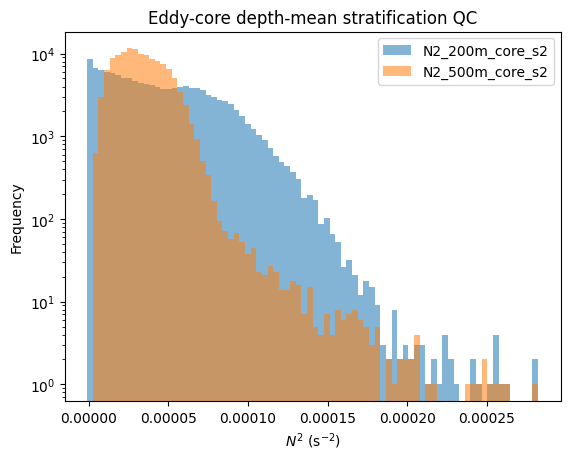

In [4]:
core_cols = ["N2_200m_core_s2", "N2_500m_core_s2"]
centre_cols = ["N2_200m_centre_s2", "N2_500m_centre_s2"]
display(n2_cache[core_cols + centre_cols].describe(percentiles=[.01, .05, .5, .95, .99]))
assert not n2_cache.duplicated(["Eddy", "Day"]).any()
for col in core_cols:
    print(col, "positive fraction:", (n2_cache[col] > 0).mean(), "missing:", n2_cache[col].isna().mean())
    if (n2_cache[col] > 0).mean() < 0.8:
        raise ValueError(f"{col} failed sign QC; check vertical-coordinate alignment.")

metric_cols = ["N2_200m_integral_m_s2_core", "N2_500m_integral_m_s2_core",
               "N2_200m_max_s2_core", "N2_500m_max_s2_core",
               "N2_pycnocline_mean_s2_core", "N2_pycnocline_max_s2_core",
               "pycnocline_depth_m_core", "MLD_density_m_core"]
display(n2_cache[metric_cols].describe(percentiles=[.01, .05, .5, .95, .99]))
display(n2_cache[["N2_core_cells", "N2_200m_core_valid_fraction", "N2_500m_core_valid_fraction"]].describe())
display(n2_cache[["N2_cache_version", "N2_cache_signature", "N2_density_method"]].drop_duplicates())
n2_cache[core_cols].plot.hist(bins=80, logy=True, alpha=.55)
plt.xlabel(r"$N^2$ (s$^{-2}$)")
plt.title("Eddy-core depth-mean stratification QC")
plt.show()


## Acceptance checks

- Confirm `temp`, `salt`, ROMS vertical coordinates, `ic → xi_rho`, and `jc → eta_rho` on several manually selected profiles.
- Investigate negative or extreme values rather than silently clipping them. The depth means retain resolved negative values.
- Compare several cached columns against direct plots of `N2(z)`.
- Record the installed `xroms` version with the final results.


In [5]:
import xroms
print("xroms", xroms.__version__)
print("cache", N2_CACHE)


xroms 0.6.2
cache /srv/scratch/z5297792/SEACOFS_26yr_eddy_dataset/tilt_mechanisms/n2_eddy_day_v4_potential_density_core.parquet
